In [ ]:
import pandas as pd
import requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Definir la URL de la API (enlace raw para obtener el JSON puro)
url_api = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

print("Iniciando conexión con la API...")

try:
    # Realizar la petición HTTP para extraer los datos con un tiempo de espera límite
    respuesta = requests.get(url_api, timeout=10)
    respuesta.raise_for_status() # Lanza una excepción si hay un error HTTP

    datos_crudos = respuesta.json()

    # Aplanar la estructura anidada del JSON para convertirla en un DataFrame
    df_telecom = pd.json_normalize(datos_crudos)

    print("Extracción exitosa.")
    print(f"Dimensiones iniciales del dataset: {df_telecom.shape[0]} filas y {df_telecom.shape[1]} columnas.\n")

    # Mostrar las primeras filas para confirmar la correcta lectura
    display(df_telecom.head())

except requests.exceptions.RequestException as e:
    print(f"Error en la extracción de datos: {e}")

Iniciando conexión con la API...
Extracción exitosa.
Dimensiones iniciales del dataset: 7267 filas y 21 columnas.



,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
print("Iniciando Parte 2: Transformación de datos...")

# --- 1. Limpieza Estructural de Columnas ---
prefijos = ['customer.', 'phone.', 'internet.', 'account.', 'Charges.']
for prefijo in prefijos:
    df_telecom.columns = df_telecom.columns.str.replace(prefijo, '', regex=False)

df_telecom.columns = df_telecom.columns.str.lower()


# --- 2. Tratamiento de Tipos de Datos y Anomalías ---
# Convertimos 'total' a numérico forzando los errores (espacios vacíos) a NaN
df_telecom['total'] = pd.to_numeric(df_telecom['total'], errors='coerce')
# Rellenamos los NaN generados (clientes con tenure 0) con 0.0
df_telecom['total'] = df_telecom['total'].fillna(0.0)


# --- 3. Traducción y Estandarización de Variables ---
traducciones = {
    'Yes': 'Sí',
    'No': 'No',
    'Male': 'Masculino',
    'Female': 'Femenino',
    'No internet service': 'Sin internet',
    'No phone service': 'Sin teléfono',
    'Month-to-month': 'Mensual',
    'One year': '1 Año',
    'Two year': '2 Años',
    'Bank transfer (automatic)': 'Transferencia',
    'Credit card (automatic)': 'Tarjeta',
    'Electronic check': 'Cheque electrónico',
    'Mailed check': 'Cheque por correo'
}
df_telecom = df_telecom.replace(traducciones)


# --- 4. Filtro de Calidad (Anomalías en la Variable Objetivo) ---
# Nos quedamos estrictamente con las filas que tengan 'Sí' o 'No' en el churn
registros_iniciales = len(df_telecom)
df_telecom = df_telecom[df_telecom['churn'].isin(['Sí', 'No'])].copy()
registros_eliminados = registros_iniciales - len(df_telecom)


# --- 5. Ingeniería de Características (Feature Engineering) ---
# 5.1 Creación de rangos de permanencia para facilitar el análisis visual
limites = [-1, 12, 24, 36, 48, 60, np.inf]
etiquetas = ['0-1 Año', '1-2 Años', '2-3 Años', '3-4 Años', '4-5 Años', 'Más de 5 Años']
df_telecom['rango_permanencia'] = pd.cut(df_telecom['tenure'], bins=limites, labels=etiquetas)

# 5.2 Codificación binaria de la variable objetivo para Machine Learning
df_telecom['churn_num'] = df_telecom['churn'].map({'Sí': 1, 'No': 0})


# --- Validación de la Transformación ---
print("Transformación completada exitosamente.\n")
print(f"Se eliminaron {registros_eliminados} registros con anomalías en la variable 'churn'.")
print(f"Filas finales listas para análisis: {len(df_telecom)}\n")
print("Primeras filas del dataset procesado:")
display(df_telecom[['customerid', 'tenure', 'rango_permanencia', 'total', 'churn', 'churn_num']].head())

Iniciando Parte 2: Transformación de datos...
Transformación completada exitosamente.

Se eliminaron 224 registros con anomalías en la variable 'churn'.
Filas finales listas para análisis: 7043

Primeras filas del dataset procesado:


,customerid,tenure,rango_permanencia,total,churn,churn_num
0,0002-ORFBO,9,0-1 Año,593.30,No,0
1,0003-MKNFE,9,0-1 Año,542.40,No,0
2,0004-TLHLJ,4,0-1 Año,280.85,Sí,1
3,0011-IGKFF,13,1-2 Años,1237.85,Sí,1
4,0013-EXCHZ,3,0-1 Año,267.40,Sí,1


Iniciando Parte 3: Generación de visualizaciones EDA...


/tmp/ipykernel_311/3213703688.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_telecom, x='churn', palette='viridis')


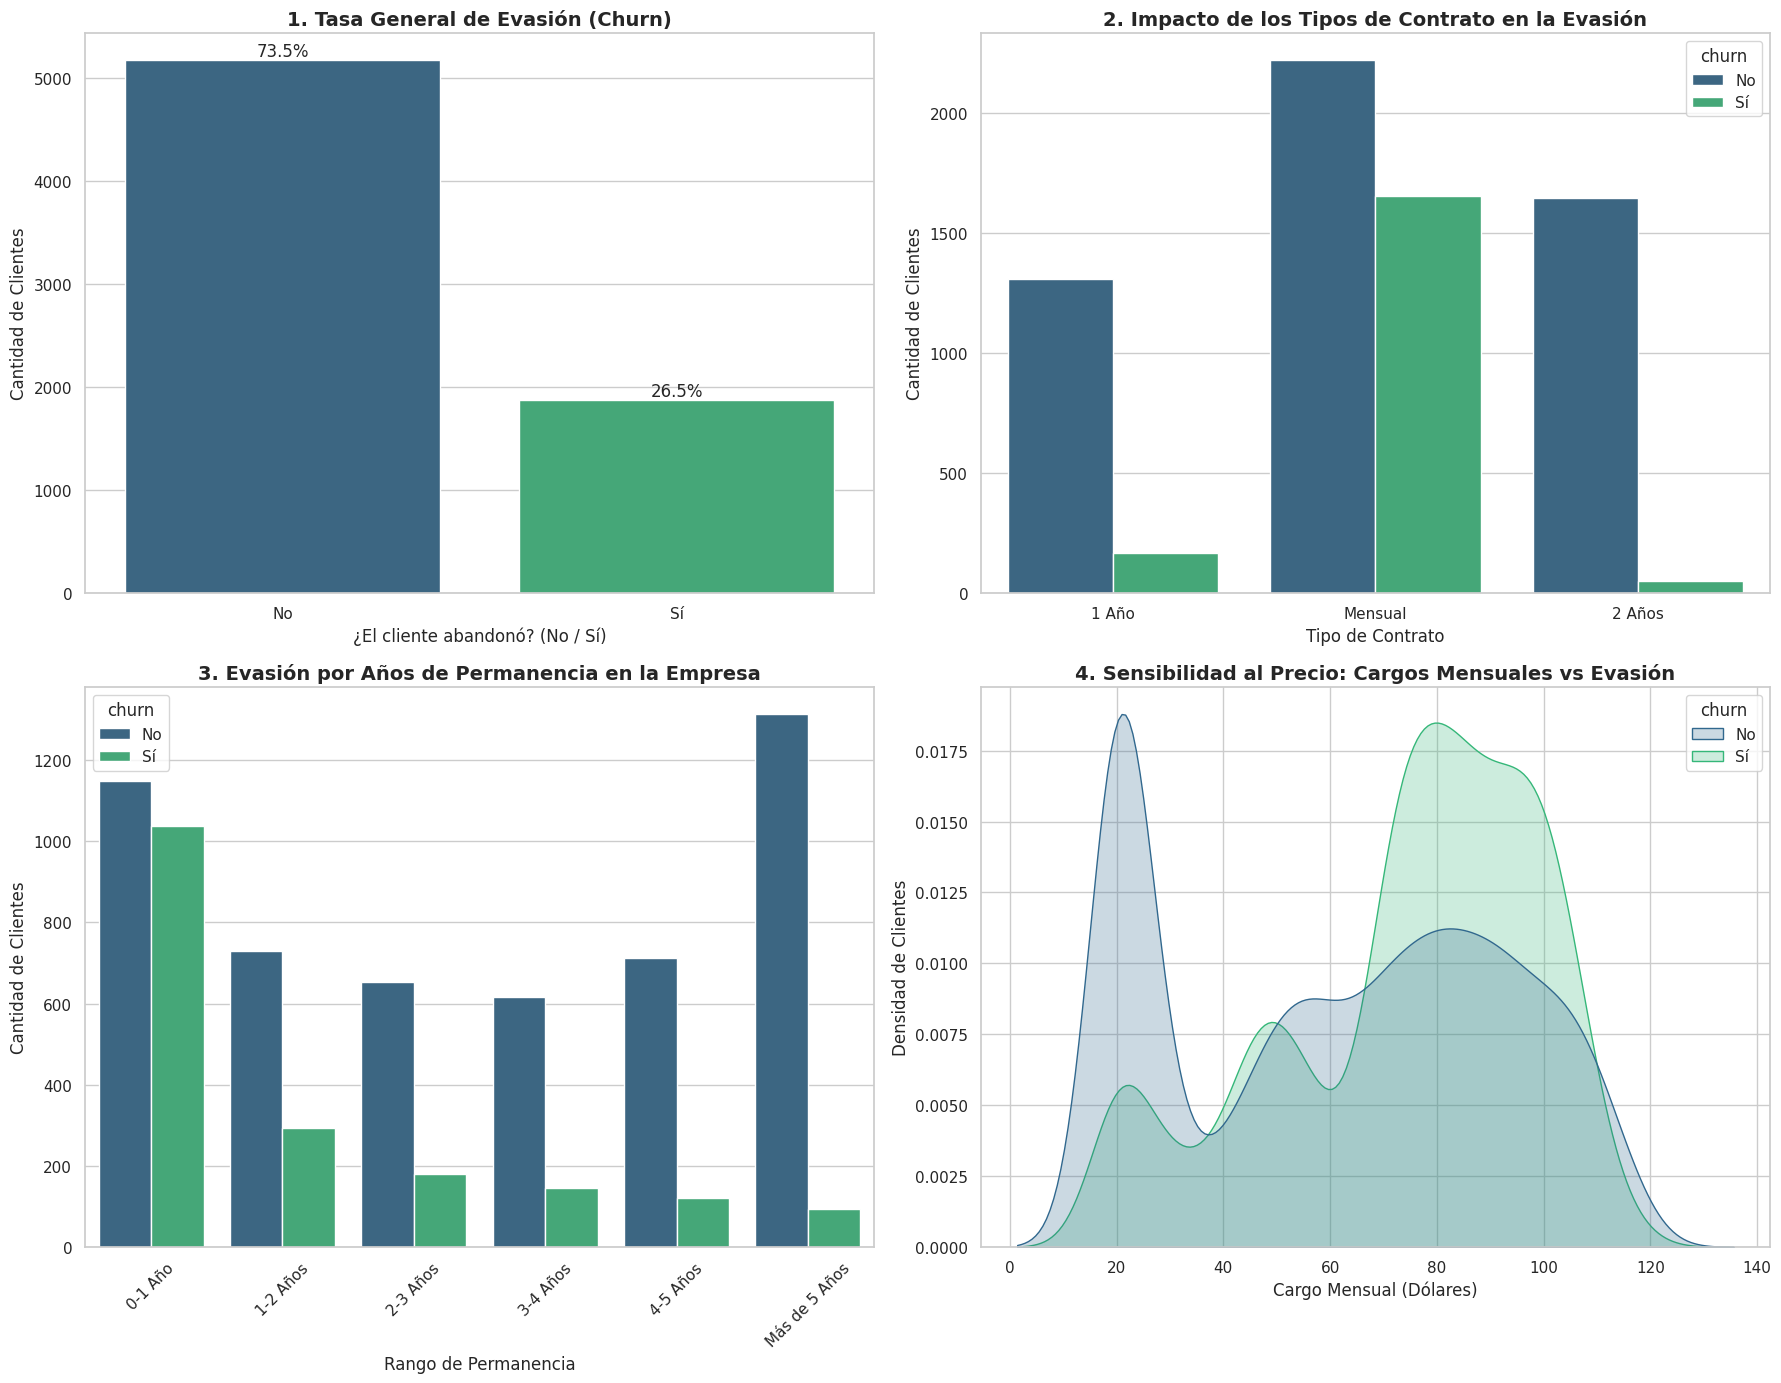

Análisis visual generado con éxito. Datos 100% binarios y limpios.


In [ ]:
print("Iniciando Parte 3: Generación de visualizaciones EDA...")

# Configuración del estilo visual general de los gráficos
sns.set_theme(style="whitegrid")
plt.figure(figsize=(18, 14))

# ==============================================================================
# GRÁFICO 1: Tasa General de Evasión (El tamaño del problema)
# ==============================================================================
plt.subplot(2, 2, 1)
ax = sns.countplot(data=df_telecom, x='churn', palette='viridis')
plt.title('1. Tasa General de Evasión (Churn)', fontsize=14, fontweight='bold')
plt.xlabel('¿El cliente abandonó? (No / Sí)')
plt.ylabel('Cantidad de Clientes')

# Agregamos los porcentajes exactos sobre las barras
total = len(df_telecom)
for p in ax.patches:
    porcentaje = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(porcentaje, (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12)

# ==============================================================================
# GRÁFICO 2: Evasión según el Tipo de Contrato
# ==============================================================================
plt.subplot(2, 2, 2)
sns.countplot(data=df_telecom, x='contract', hue='churn', palette='viridis')
plt.title('2. Impacto de los Tipos de Contrato en la Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Cantidad de Clientes')

# ==============================================================================
# GRÁFICO 3: Evasión por Tiempo de Permanencia (El Valle de la Muerte)
# ==============================================================================
plt.subplot(2, 2, 3)
sns.countplot(data=df_telecom, x='rango_permanencia', hue='churn', palette='viridis')
plt.title('3. Evasión por Años de Permanencia en la Empresa', fontsize=14, fontweight='bold')
plt.xlabel('Rango de Permanencia')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)

# ==============================================================================
# GRÁFICO 4: Distribución de Cargos Mensuales vs Evasión (El Factor Precio)
# ==============================================================================
plt.subplot(2, 2, 4)
sns.kdeplot(data=df_telecom, x='monthly', hue='churn', fill=True, palette='viridis', common_norm=False)
plt.title('4. Sensibilidad al Precio: Cargos Mensuales vs Evasión', fontsize=14, fontweight='bold')
plt.xlabel('Cargo Mensual (Dólares)')
plt.ylabel('Densidad de Clientes')

# Ajustamos el layout para que no se superpongan los textos
plt.tight_layout()
plt.show()

print("Análisis visual generado con éxito. Datos 100% binarios y limpios.")

INFORME DE ANÁLISIS DE EVASIÓN DE CLIENTES

Proyecto: Telecom X

1. Diagnóstico General
Tras procesar y limpiar la base de datos de Telecom X, identificamos que la empresa se enfrenta a un problema severo de retención. Aproximadamente el 26.5% de la base de clientes válida ha abandonado los servicios. Esta tasa de evasión compromete la rentabilidad y exige medidas de contención inmediatas.

2. Hallazgos Clave (Puntos de Fuga)
El Análisis Exploratorio de Datos (EDA) reveló tres patrones críticos que explican el comportamiento de los usuarios que deciden darse de baja:

Vulnerabilidad del Corto Plazo: La inmensa mayoría de las cancelaciones provienen de usuarios con un plan Mensual. Los clientes que adquieren compromisos de 1 o 2 años presentan una lealtad altísima y una tasa de evasión casi nula.

El "Valle de la Muerte" del Primer Año: El mayor riesgo de abandono ocurre durante los primeros 12 meses de servicio. Si el cliente supera la barrera de los dos años en la empresa, la probabilidad de que cancele se reduce drásticamente.

Sensibilidad al Precio (Cargos Mensuales): Existe un alto volumen de evasión en el segmento de clientes que pagan las tarifas más altas (entre $70 y $100 dólares). Esto sugiere una fuerte insatisfacción con el ratio costo-beneficio de los paquetes premium o de los servicios complementarios (como fibra óptica o soporte técnico extra).

3. Recomendaciones Estratégicas
Para mitigar la pérdida de clientes, se sugieren las siguientes acciones de negocio:

Campaña de Migración de Contratos: Implementar incentivos agresivos (descuentos en los primeros meses o mejoras de velocidad sin costo) para convencer a los clientes mensuales de firmar contratos anuales.

Fidelización Temprana: Crear un programa de onboarding proactivo y atención preferencial durante el primer año de vida del cliente para asegurar que superen la etapa de mayor riesgo.

Revisión de Precios Premium: Analizar el valor percibido de los servicios más costosos. Si los clientes que más pagan son los que más se van, la empresa debe justificar mejor ese precio o ajustar las tarifas.

4. Estado de los Datos (Para el Equipo de Machine Learning)
El dataset adjunto ha superado el pipeline de ETL:

Limpieza: Estructura de columnas estandarizada y nulos imputados en variables financieras (total).

Traducción: Variables categóricas estandarizadas al español.

Calidad de Variable Objetivo: Se eliminaron los registros anómalos (en blanco) en la columna churn. La variable es ahora estrictamente binaria y ha sido codificada numéricamente (churn_num = 1 y 0).

Próximos pasos sugeridos para modelado: Aplicar codificación One-Hot para el resto de variables categóricas y utilizar técnicas de balanceo (como SMOTE) debido a la desproporción actual entre retención y abandono.